In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(291,495)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
def getSSByRes_ts(trjpaths,tprpaths,EQPOINT):
    
    helicityMap={"H":1,"E":0,"C":0}
    betacityMap={"H":0,"E":1,"C":0}
    coilicityMap={"H":0,"E":0,"C":1}
    
    helicity= []
    betacity= []
    coilicity=[]
    
    herr=[]
    berr=[]
    cerr=[]
    
    for i in range(len(trjpaths)):
        subH=[]
        subE=[]
        subC=[]
        for j in range(len(trjpaths[i])):
            t=mdtraj.load(trjpaths[i][j],top=tprpaths[i][j])
            ss1=mdtraj.compute_dssp(t,simplified=True)
            H1=zeros(ss1.shape)
            E1=zeros(ss1.shape)
            C1=zeros(ss1.shape)
            
            for ii in range(len(H1)):
                for jj in range(len(H1[ii])):
                    H1[ii][jj]=helicityMap[ss1[ii][jj]]
                    E1[ii][jj]=betacityMap[ss1[ii][jj]]
                    C1[ii][jj]=coilicityMap[ss1[ii][jj]]
                    
            H1byRes=H1[EQPOINT:]
            subH.append(H1byRes)
            
            E1byRes=E1[EQPOINT:]
            subE.append(E1byRes)
            C1byRes=C1[EQPOINT:]
            subC.append(C1byRes)
            
        helicity.append(subH)
        betacity.append(subE)
        coilicity.append(subC)

    return helicity,betacity,coilicity


helicity_ts,betacity_ts,coilicity_ts=getSSByRes_ts(systemtrjs,systemgros,EQPOINT=EQPOINT)

C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (LEU, GLU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (THR, LEU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ASP, THR)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, ASP)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ARG, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (CYS, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (GLU, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

In [4]:
allrgs=load("allrgs.npy")



C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


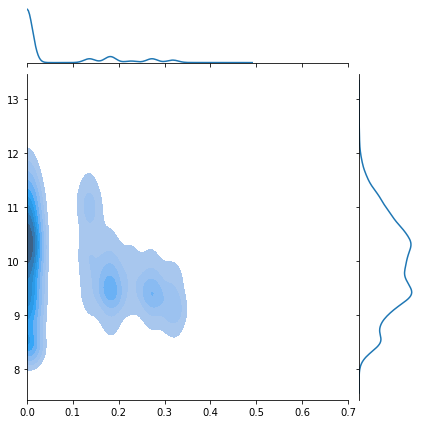

In [5]:
sns.jointplot(mean(array(list(helicity_ts[1]))[:,:,34:56],axis = 2).flatten(),allrgs[1].flatten(),kind = 'kde',shade = True,xlim = (0,0.7))

C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


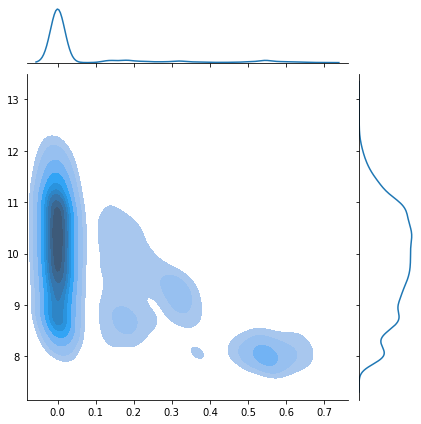

In [6]:
sns.jointplot(mean(array(list(helicity_ts[2]))[:,:,34:56],axis = 2).flatten(),allrgs[2].flatten(),kind = 'kde',shade = True)

In [7]:
array(list(helicity_ts[1])).shape

(9, 4001, 202)